In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from epymodelingsuite.multistrain.formatter import (
    compute_quantiles,
    add_state_abbreviations,
    create_ed_submission,
    create_ed_quantile_submission,
    STATE_ABBREV,
    LOCATION_CODES,
)
from epymodelingsuite.multistrain.aggregator import pull_single_strain_submission
from epymodelingsuite.schema.output import (
    get_flusight_quantiles,
    get_flusight_horizons
)

## Configuration

Set timespan configs:

In [2]:
SUBMISSION_WEEK = "202617"
REFERENCE_DATE = "2026-05-02"
WINDOW = "202550-202616"

These configs are unlikely to need changing:

In [3]:
DIST_FUNC = "wrmse"
STRAINS = "h1-h3-b"
TARGET = "ed"
TARGET_LONG = "flu_prop-ed_25"

Derived config values:

In [4]:
REFERENCE_DT = pd.to_datetime(REFERENCE_DATE)
final_date = REFERENCE_DT + pd.Timedelta(weeks=4)
final_date

Timestamp('2026-05-30 00:00:00')

## Data

In [5]:
# Load single-strain submission file
single_source_experiment = f"gs://gs_mobs_jessica/pipeline/flu/{SUBMISSION_WEEK}/{TARGET}_smc_{DIST_FUNC}_{WINDOW}"
single_fname = f"output_hub_formatted.csv.gz"
df_single = pull_single_strain_submission(source_location=single_source_experiment, fname=single_fname)
df_single.head()

Copying gs://gs_mobs_jessica/pipeline/flu/202617/ed_smc_wrmse_202550-202616/20260429-184810-5e90330f/outputs/20260429-205728_ed-prop/output_hub_formatted.csv.gz to file:///tmp/tmpupb50i9t/output_hub_formatted.csv.gz
  


Downloaded: output_hub_formatted.csv.gz


.


,location,reference_date,horizon,target_end_date,target,output_type,output_type_id,value
0,US,2026-05-02,-1,2026-04-25,wk inc flu prop ed visits,quantile,0.01,0.0
1,US,2026-05-02,0,2026-05-02,wk inc flu prop ed visits,quantile,0.01,0.0
2,US,2026-05-02,1,2026-05-09,wk inc flu prop ed visits,quantile,0.01,0.0
3,US,2026-05-02,2,2026-05-16,wk inc flu prop ed visits,quantile,0.01,0.0
4,US,2026-05-02,-1,2026-04-25,wk inc flu prop ed visits,quantile,0.025,0.0


In [6]:
# Load ground truth hospital data
fit_surv_data = pd.read_csv(f"../flu-forecast-epydemix/common-data/surveillance/{TARGET_LONG}_{SUBMISSION_WEEK}_scaled_multi.csv")
fit_surv_data['abbreviation'] = fit_surv_data['location_iso'].apply(lambda key: key.split("-")[-1])
fit_surv_data['date'] = pd.to_datetime(fit_surv_data['date'])

# Compute quantiles for both sampling methods
random_combined = pd.read_csv(f"../experiments/multistrain/{SUBMISSION_WEEK}-{TARGET}/multi_{TARGET}_smc_{DIST_FUNC}_{WINDOW}_{STRAINS}/trajectories_aggregated.csv")
random_quantiles = compute_quantiles(random_combined)

# Add abbreviations
random_quantiles = add_state_abbreviations(random_quantiles)
random_quantiles['date'] = pd.to_datetime(random_quantiles['date'])

# Get sorted list of populations (US first, then states alphabetically)
populations = sorted(random_quantiles['location'].unique())
populations = ['United_States'] + [p for p in populations if p != 'United_States']

print(f"Plotting {len(populations)} locations")

Plotting 51 locations


In [7]:
print(f"Quantiles shape: {random_quantiles.shape}")
print(f"Quantile columns: {[c for c in random_quantiles.columns if c.startswith('q')]}")
random_quantiles.head(10)

Quantiles shape: (1785, 26)
Quantile columns: ['q010', 'q025', 'q050', 'q100', 'q150', 'q200', 'q250', 'q300', 'q350', 'q400', 'q450', 'q500', 'q550', 'q600', 'q650', 'q700', 'q750', 'q800', 'q850', 'q900', 'q950', 'q975', 'q990']


,location,date,q010,q025,q050,q100,q150,q200,q250,q300,...,q650,q700,q750,q800,q850,q900,q950,q975,q990,abbreviation
0,United_States,2025-09-20,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000167,0.001121,0.001528,0.003199,US
1,United_States,2025-09-27,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000235,0.001297,0.002287,0.004934,0.006571,0.009899,US
2,United_States,2025-10-04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000090,0.000903,0.001767,0.002253,0.003334,0.005661,0.006746,0.009499,US
3,United_States,2025-10-11,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.001524,0.001864,0.002433,0.002946,0.003952,0.005244,0.006838,0.008913,0.012464,US
4,United_States,2025-10-18,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.002477,0.003032,0.003626,0.004473,0.005590,0.007000,0.009040,0.010850,0.014477,US
5,United_States,2025-10-25,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000581,...,0.003648,0.004275,0.004989,0.005743,0.006570,0.008106,0.010218,0.012766,0.015174,US
6,United_States,2025-11-01,0.000000,0.000000,0.000000,0.000000,0.000242,0.000975,0.001488,0.001855,...,0.004994,0.005514,0.006053,0.006946,0.008338,0.009442,0.011726,0.014165,0.018049,US
7,United_States,2025-11-08,0.000000,0.000000,0.000000,0.000629,0.001553,0.002000,0.002487,0.002797,...,0.006285,0.006978,0.007635,0.008535,0.009440,0.011074,0.013636,0.016960,0.021044,US
8,United_States,2025-11-15,0.000000,0.000391,0.001269,0.002059,0.002781,0.003266,0.003642,0.004090,...,0.007658,0.008299,0.009085,0.010442,0.011609,0.013020,0.015775,0.018300,0.022875,US
9,United_States,2025-11-22,0.001498,0.002398,0.003111,0.003949,0.004636,0.005122,0.005754,0.006315,...,0.010096,0.010857,0.011780,0.012787,0.014428,0.016176,0.019099,0.022061,0.025709,US


## Plot

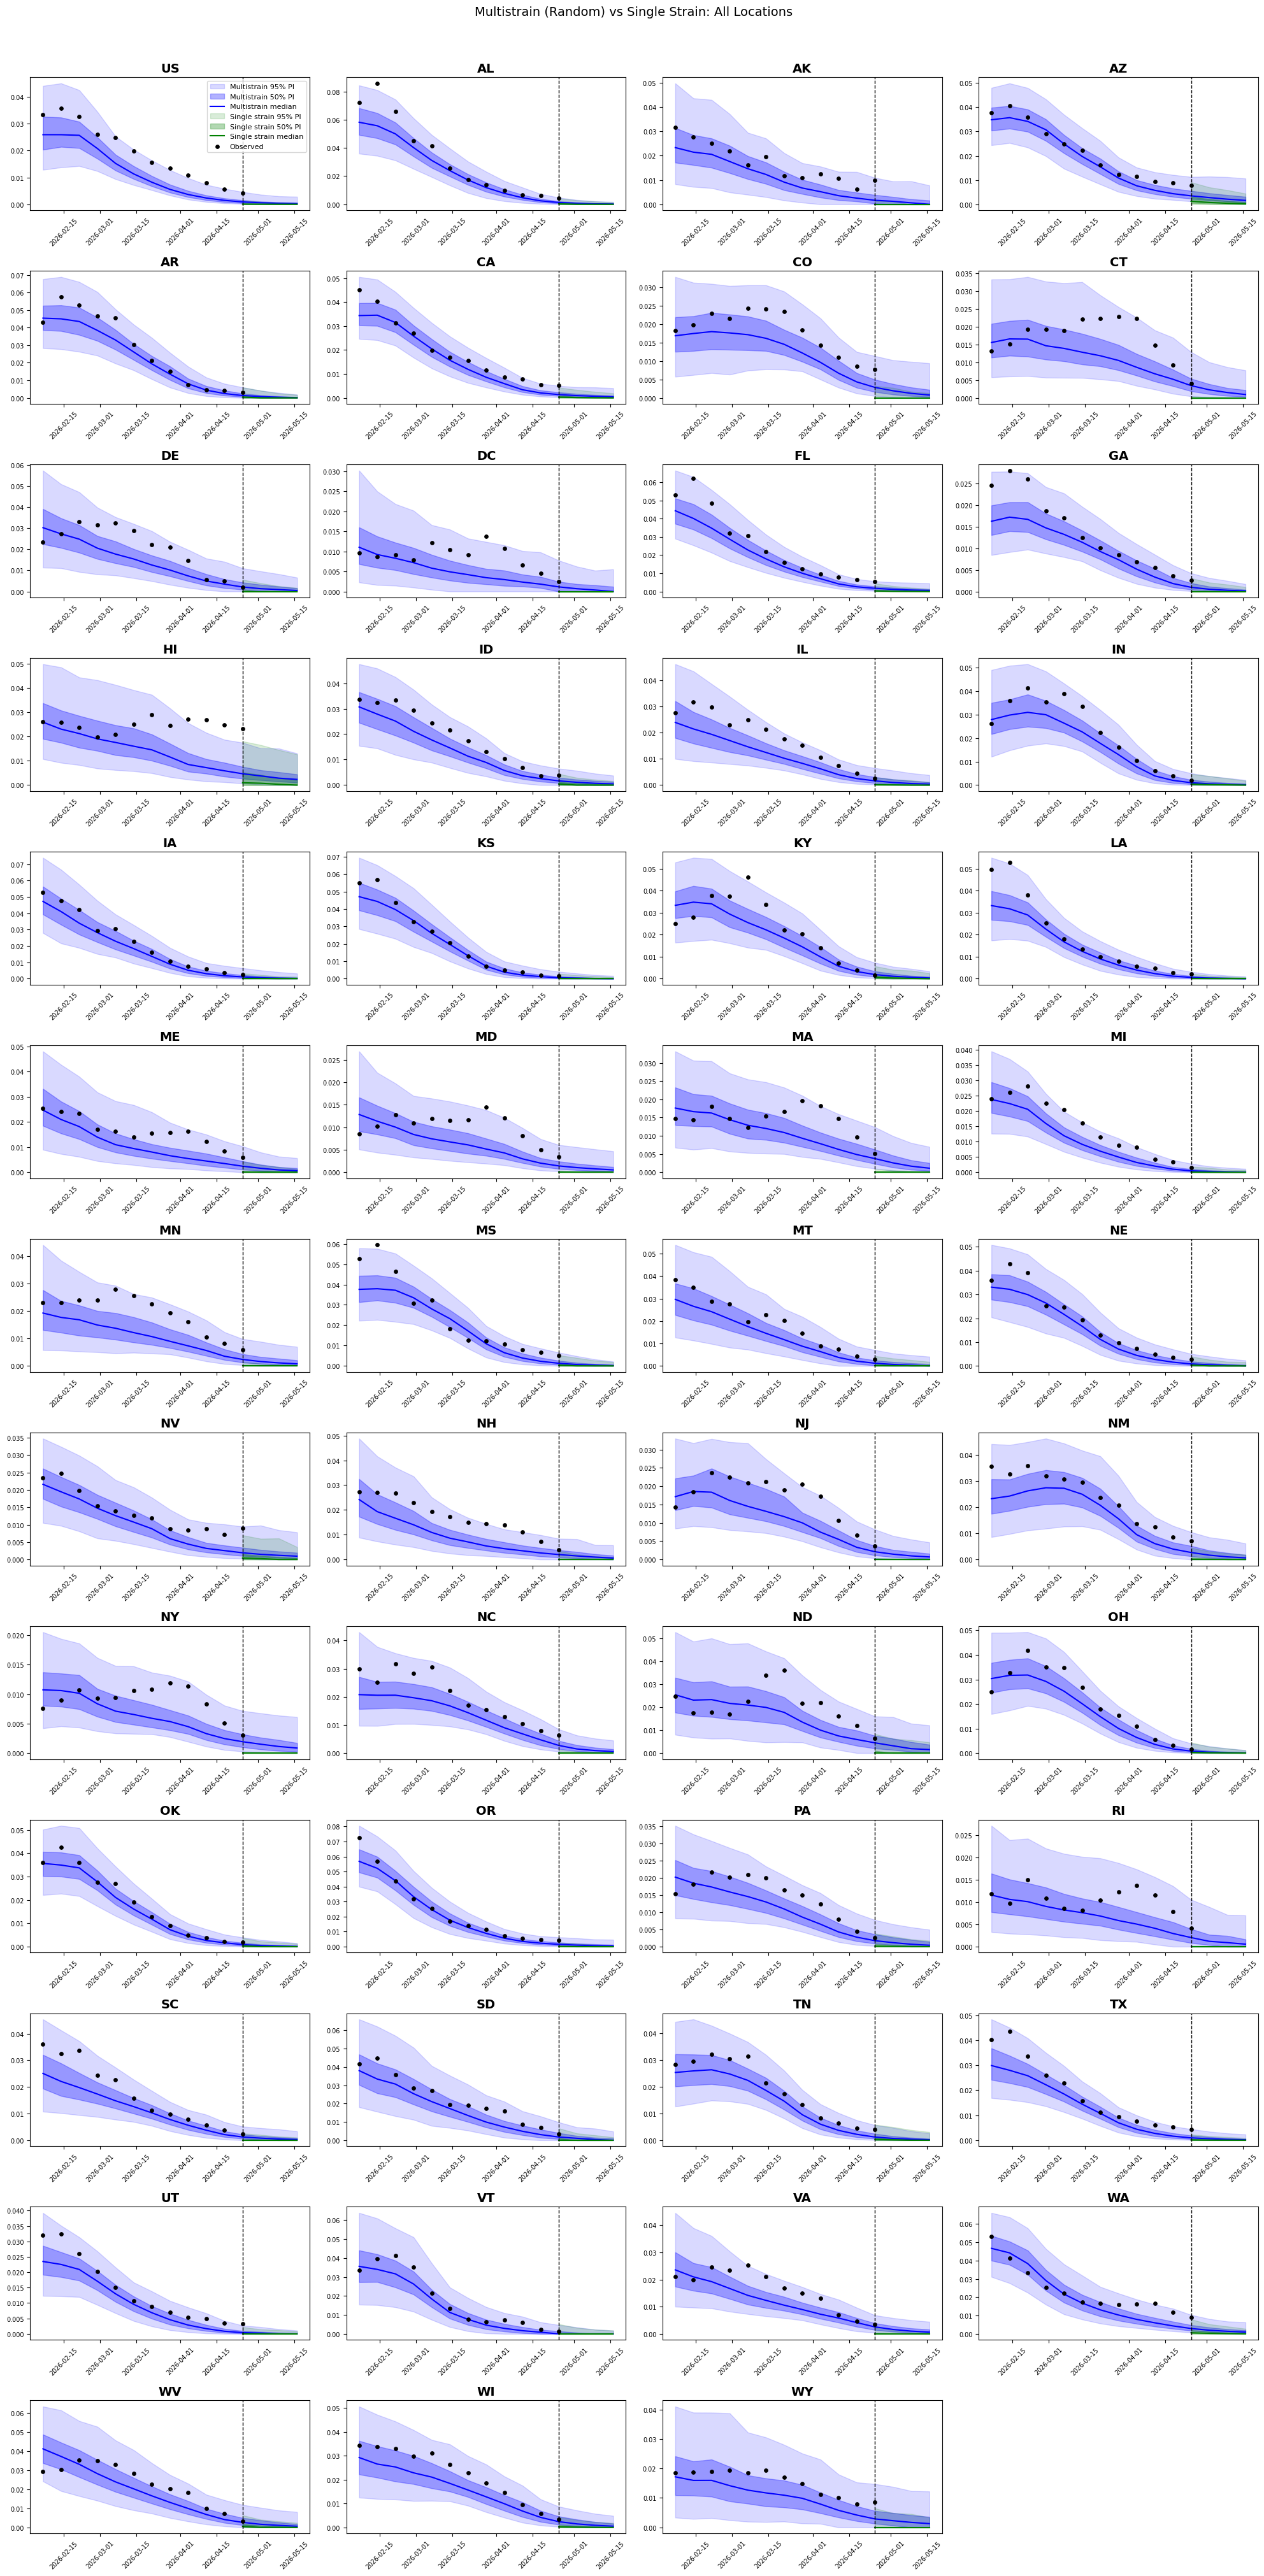

In [13]:
FILTER_PLOT = True

if FILTER_PLOT:
    plot_start_date = pd.to_datetime('2026-02-01')
    plot_prefix = 'filtered_'
else:
    plot_start_date = pd.to_datetime('2025-10-01')
    plot_prefix = ''

random_quantiles_filter = random_quantiles[(random_quantiles['date'] >= plot_start_date) & (random_quantiles['date'] < final_date)]

fit_surv_data_filter = fit_surv_data[(fit_surv_data['date'] >= plot_start_date) & (fit_surv_data['date'] < final_date)]



# Convert df_single to wide format for plotting (matching random_quantiles format)
df_single_quantiles = df_single[df_single['output_type'] == 'quantile'].copy()
df_single_quantiles['target_end_date'] = pd.to_datetime(df_single_quantiles['target_end_date'])

# Pivot to get quantile columns
df_single_wide = df_single_quantiles.pivot_table(
    index=['location', 'target_end_date'],
    columns='output_type_id',
    values='value'
).reset_index()

# Rename columns to match random_quantiles format
df_single_wide.columns.name = None
df_single_wide = df_single_wide.rename(columns={
    'target_end_date': 'date',
    '0.025': 'q025', '0.25': 'q250', '0.5': 'q500', '0.75': 'q750', '0.975': 'q975'
})

# Filter to date range
df_single_filter = df_single_wide[
    (df_single_wide['date'] >= plot_start_date) & 
    (df_single_wide['date'] < final_date)
]

# Create 13x4 comparison figure: Random multistrain vs Single strain
fig, axes = plt.subplots(13, 4, figsize=(20, 40))
axes = axes.flatten()

for idx, pop in enumerate(populations):
    ax = axes[idx]
    abbrev = STATE_ABBREV.get(pop, pop)
    location_code = LOCATION_CODES.get(abbrev, abbrev)
    
    # Get data for this population
    rand_pop = random_quantiles_filter[random_quantiles_filter['location'] == pop].sort_values('date')
    single_pop = df_single_filter[df_single_filter['location'] == location_code].sort_values('date')
    fit_surv_data_pop = fit_surv_data_filter[fit_surv_data_filter['abbreviation'] == abbrev].sort_values('date')
    
    # Plot random multistrain sampling (blue)
    ax.fill_between(rand_pop['date'], rand_pop['q025'], rand_pop['q975'], 
                    alpha=0.15, color='blue', label='Multistrain 95% PI')
    ax.fill_between(rand_pop['date'], rand_pop['q250'], rand_pop['q750'], 
                    alpha=0.3, color='blue', label='Multistrain 50% PI')
    ax.plot(rand_pop['date'], rand_pop['q500'], 'b-', linewidth=1.5, label='Multistrain median')
    
    # Plot single strain (green)
    ax.fill_between(single_pop['date'], single_pop['q025'], single_pop['q975'], 
                    alpha=0.15, color='green', label='Single strain 95% PI')
    ax.fill_between(single_pop['date'], single_pop['q250'], single_pop['q750'], 
                    alpha=0.3, color='green', label='Single strain 50% PI')
    ax.plot(single_pop['date'], single_pop['q500'], 'g-', linewidth=1.5, label='Single strain median')
    
    # Plot ground truth (black markers)
    ax.scatter(fit_surv_data_pop['date'], fit_surv_data_pop['original_value'], 
               color='black', s=15, zorder=5, label='Observed')
    
    ax.set_title(abbrev, fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.axvline(REFERENCE_DT - pd.Timedelta(weeks=1), color='black', linestyle='--', linewidth=1)
    
    # Only show legend for first subplot
    if idx == 0:
        ax.legend(fontsize=8, loc='upper right')

# Hide any unused subplots
for idx in range(len(populations), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Multistrain (Random) vs Single Strain: All Locations', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'../experiments/multistrain/{SUBMISSION_WEEK}-{TARGET}/multi_{TARGET}_smc_{DIST_FUNC}_{WINDOW}_{STRAINS}/{plot_prefix}multi_{TARGET}_smc_{DIST_FUNC}_{WINDOW}_{STRAINS}_multistrain_vs_single_comparison.pdf', 
            dpi=150, bbox_inches='tight')
plt.show()

## Submission File

In [9]:
# Create complete FluSight submission
submission = create_ed_submission(
    trajectories_df=random_combined,
    reference_date=REFERENCE_DATE,
    horizons=get_flusight_horizons(),  # -1 is nowcast, 0-3 are forecasts
    value_col='target_total'
)

print(f"Submission shape: {submission.shape}")
print(f"\nColumns: {submission.columns.tolist()}")
print(f"\nTargets: {submission['target'].unique()}")
print(f"Output types: {submission['output_type'].unique()}")
print(f"Horizons: {sorted(submission['horizon'].unique())}")
print(f"Locations: {submission['location'].nunique()}")
print(f"\nRows per target:")
print(submission.groupby(['target', 'output_type']).size())

Submission shape: (4692, 8)

Columns: ['reference_date', 'horizon', 'target_end_date', 'location', 'target', 'output_type', 'output_type_id', 'value']

Targets: <StringArray>
['wk inc flu prop ed visits']
Length: 1, dtype: str
Output types: <StringArray>
['quantile']
Length: 1, dtype: str
Horizons: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]
Locations: 51

Rows per target:
target                     output_type
wk inc flu prop ed visits  quantile       4692
dtype: int64


In [10]:
submission

,reference_date,horizon,target_end_date,location,target,output_type,output_type_id,value
0,2026-05-02,-1,2026-04-25,01,wk inc flu prop ed visits,quantile,0.01,0.000
1,2026-05-02,-1,2026-04-25,01,wk inc flu prop ed visits,quantile,0.025,0.000
2,2026-05-02,-1,2026-04-25,01,wk inc flu prop ed visits,quantile,0.05,0.000
3,2026-05-02,-1,2026-04-25,01,wk inc flu prop ed visits,quantile,0.1,0.000
4,2026-05-02,-1,2026-04-25,01,wk inc flu prop ed visits,quantile,0.15,0.000
...,...,...,...,...,...,...,...,...
4687,2026-05-02,2,2026-05-16,US,wk inc flu prop ed visits,quantile,0.85,0.001
4688,2026-05-02,2,2026-05-16,US,wk inc flu prop ed visits,quantile,0.9,0.001
4689,2026-05-02,2,2026-05-16,US,wk inc flu prop ed visits,quantile,0.95,0.002
4690,2026-05-02,2,2026-05-16,US,wk inc flu prop ed visits,quantile,0.975,0.003


In [11]:
submission.to_csv(f"../experiments/multistrain/{SUBMISSION_WEEK}-{TARGET}/multi_{TARGET}_smc_{DIST_FUNC}_{WINDOW}_{STRAINS}/{REFERENCE_DATE}-MOBS-EpyStrain_Flu.csv",
                  index=False)